In [ ]:
!pip install open_clip_torch > /dev/null

import os
import numpy as np
import pandas as pd
import torch
import cv2
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import open_clip
from PIL import Image
from sklearn.metrics import (roc_auc_score, accuracy_score, confusion_matrix,
                             roc_curve, recall_score, f1_score, balanced_accuracy_score)

from google.colab import drive
drive.mount('/content/drive')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Paths
base_path = "/content/drive/MyDrive/MrNet-v1/MRNet-v1.0"
axial_dir = base_path + "/merged_data/axial"
coronal_dir  = base_path + "/merged_data/coronal"
sagittal_dir = base_path + "/merged_data/sagittal"
val_df = pd.read_csv(base_path + "/test_split.csv")

# Load CLIP

print("Loading ConvNeXt CLIP (CNN-based)...")
model_name = 'convnext_base_w'
pretrained_weights = 'laion2b_s13b_b82k'

model, _, preprocess = open_clip.create_model_and_transforms(model_name, pretrained=pretrained_weights)
model = model.to(device)
model.eval()
tokenizer = open_clip.get_tokenizer(model_name)
model_title = "ConvNeXt CLIP"
print("Loaded successfully!")

Mounted at /content/drive
Using device: cuda
Loading ConvNeXt CLIP (CNN-based)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/718M [00:00<?, ?B/s]

Loaded successfully!


In [ ]:
######################################################
#the first one with good results


def get_ensembled_text_features(plane_name):

    prompts_healthy =[
        f"A normal {plane_name} MRI slice of the knee with an intact anterior cruciate ligament.",
        f"Healthy knee MRI {plane_name} view showing a continuous ACL with low signal intensity.",
        f"No ligamentous injury, intact anterior cruciate ligament in {plane_name} plane."
    ]

    prompts_tear =[
        f"A {plane_name} MRI slice of the knee showing a complete tear of the anterior cruciate ligament.",
        f"Ruptured anterior cruciate ligament with high signal intensity and discontinuity in {plane_name} view.",
        f"Abnormal {plane_name} knee MRI showing an ACL tear."
    ]



    with torch.no_grad():
        tok_healthy = tokenizer(prompts_healthy).to(device)
        feat_healthy = model.encode_text(tok_healthy).mean(dim=0, keepdim=True)

        tok_tear = tokenizer(prompts_tear).to(device)
        feat_tear = model.encode_text(tok_tear).mean(dim=0, keepdim=True)

        text_features = torch.cat([feat_healthy, feat_tear], dim=0)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

    return text_features

In [ ]:
class BioMedCLIP_MRNetDataset(Dataset):
    def __init__(self, df, plane_dir, preprocess_fn):
        self.df = df
        self.plane_dir = plane_dir
        self.preprocess = preprocess_fn

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        patient_id = str(self.df.iloc[idx]["id"]).zfill(4)
        label = self.df.iloc[idx]["label"]

        vol = np.load(os.path.join(self.plane_dir, patient_id + ".npy"))

        # IMPROVEMENT: Volume-Level Min-Max Normalization
        # Preserves relative contrast between slices (empty slices stay dark, tissue stays bright)
        vol = (vol - vol.min()) / (vol.max() - vol.min() + 1e-6)

        processed_slices =[]
        for i in range(vol.shape[0]):
            slice_img = cv2.resize(vol[i], (224, 224))

            # Scale to 0-255 for Image conversion
            slice_img = (slice_img * 255).astype(np.uint8)

            # Stack to 3 channels (RGB required by ViT)
            slice_rgb = np.stack((slice_img,)*3, axis=-1)

            # BioMedCLIP Preprocessing
            img_pil = Image.fromarray(slice_rgb)
            img_tensor = self.preprocess(img_pil)
            processed_slices.append(img_tensor)

        # Returns a variable length tensor:[num_slices, 3, 224, 224]
        return torch.stack(processed_slices), torch.tensor(label, dtype=torch.float32), patient_id

In [ ]:
def extract_plane_probabilities(plane_name, plane_dir):
    print(f"Extracting features for {plane_name.upper()}...")
    text_features = get_ensembled_text_features(plane_name)

    dataset = BioMedCLIP_MRNetDataset(val_df, plane_dir, preprocess)
    loader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=2)

    patient_probs = []
    labels =[]
    suspicious_slices = {}

    # Temperature parameter to soften the extremely peaky CLIP logits
    temperature = 2.0

    with torch.no_grad():
        for imgs, lbl, p_id in loader:
            imgs = imgs.squeeze(0).to(device) # Shape [variable_num_slices, 3, 224, 224]
            lbl = lbl.item()
            p_id = p_id[0]

            image_features = model.encode_image(imgs)
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)

            logit_scale = model.logit_scale.exp()
            # Apply Temperature Scaling
            logits_per_image = (logit_scale * image_features @ text_features.t()) / temperature
            probs = logits_per_image.softmax(dim=-1)

            prob_tear_per_slice = probs[:, 1].cpu().numpy()

            # IMPROVEMENT: Spatially Smooth the Slice Probabilities
            # ACL tears typically span across 2-4 contiguous slices.
            if len(prob_tear_per_slice) >= 3:
                kernel = np.ones(3) / 3.0
                smoothed_probs = np.convolve(prob_tear_per_slice, kernel, mode='valid')

                patient_prob_tear = np.max(smoothed_probs)
                most_suspicious_idx = np.argmax(smoothed_probs) + 1 # +1 accounts for the window shift
            else:
                # Fallback just in case a volume is abnormally small
                patient_prob_tear = np.max(prob_tear_per_slice)
                most_suspicious_idx = np.argmax(prob_tear_per_slice)

            suspicious_slices[p_id] = most_suspicious_idx
            patient_probs.append(patient_prob_tear)
            labels.append(lbl)

    return np.array(patient_probs), np.array(labels), suspicious_slices

Extracting features for AXIAL...
Extracting features for CORONAL...
Extracting features for SAGITTAL...

ZERO-SHOT ENSEMBLE RESULTS (Weighted Fusion)
Optimal decision threshold found: 0.5747
Standard Accuracy:  0.6240
Balanced Accuracy:  0.6235
AUC:               0.5763
Sensitivity:       0.6226 (Recall for Tears)
Specificity:       0.6244 (Recall for Healthy)
F1-Score:          0.4125
Confusion Matrix:  TN=123, FP=74, FN=20, TP=33



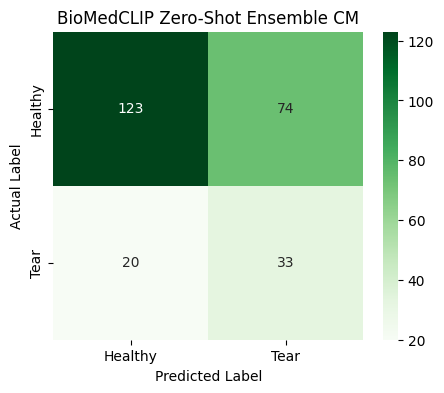

In [ ]:
# 1. Gather probabilities for all planes independently
axial_probs, y_true, axial_explain = extract_plane_probabilities("axial", axial_dir)
coronal_probs, _, coronal_explain = extract_plane_probabilities("coronal", coronal_dir)
sagittal_probs, _, sagittal_explain = extract_plane_probabilities("sagittal", sagittal_dir)

# 2. IMPROVEMENT: Radiology-Weighted Multi-Plane Fusion
# Sagittal is the gold standard for ACL tears, Coronal is secondary, Axial is least informative.
ensemble_probs = (0.6 * sagittal_probs) + (0.3 * coronal_probs) + (0.1 * axial_probs)

# 3. Find optimal threshold using Youden's J statistic
fpr, tpr, thresholds = roc_curve(y_true, ensemble_probs)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print(f"\n" + "="*50)
print("ZERO-SHOT ENSEMBLE RESULTS (Weighted Fusion)")
print("="*50)
print(f"Optimal decision threshold found: {optimal_threshold:.4f}")

# Calculate final metrics using the optimal threshold

final_preds = (ensemble_probs >= optimal_threshold).astype(int)

# 1. Calculate ALL Metrics
acc = accuracy_score(y_true, final_preds)
bal_acc = balanced_accuracy_score(y_true, final_preds)
auc = roc_auc_score(y_true, ensemble_probs)
sens = recall_score(y_true, final_preds)
f1 = f1_score(y_true, final_preds)
tn, fp, fn, tp = confusion_matrix(y_true, final_preds).ravel()
spec = tn / (tn + fp) if (tn + fp) > 0 else 0

# 2. Print Detailed Report
print(f"Standard Accuracy:  {acc:.4f}")
print(f"Balanced Accuracy:  {bal_acc:.4f}")
print(f"AUC:               {auc:.4f}")
print(f"Sensitivity:       {sens:.4f} (Recall for Tears)")
print(f"Specificity:       {spec:.4f} (Recall for Healthy)")
print(f"F1-Score:          {f1:.4f}")
print(f"Confusion Matrix:  TN={tn}, FP={fp}, FN={fn}, TP={tp}\n")

# Confusion Matrix
cm = confusion_matrix(y_true, final_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Healthy', 'Tear'], yticklabels=['Healthy', 'Tear'])
plt.title(f"BioMedCLIP Zero-Shot Ensemble CM")
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
def generate_vlm_saliency_heatmap(img_tensor, plane_name):
    model.eval()
    model.zero_grad()

    # Get the text features (we specifically want the "Tear" feature, which is index 1)
    text_features = get_ensembled_text_features(plane_name)
    tear_feature = text_features[1:2] # Shape [1, 512]

    # Prepare image tensor for gradients
    single_slice = img_tensor.clone().detach().to(device)
    single_slice.requires_grad_()

    # Forward pass for image
    image_features = model.encode_image(single_slice)
    image_features = image_features / image_features.norm(dim=-1, keepdim=True)

    # Calculate similarity strictly with the "Tear" prompt
    logit_scale = model.logit_scale.exp()
    similarity = (logit_scale * image_features @ tear_feature.t()).squeeze()

    # Backpropagate from the similarity score!
    similarity.backward()

    # Extract gradients from the image pixels
    saliency = single_slice.grad.data.abs().squeeze().cpu().numpy()
    saliency = np.max(saliency, axis=0) # Max over RGB channels

    # Smooth and Normalize
    saliency = cv2.GaussianBlur(saliency, (11, 11), 0)
    if saliency.max() != saliency.min():
        saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)
    else:
        saliency = np.zeros_like(saliency)

    heatmap = np.uint8(255 * saliency)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    return heatmap_color

In [ ]:
def visualize_most_suspicious_slice(patient_idx=0, plane="sagittal"):
    """
    Loads a patient's volume and plots the exact slice that BioMedCLIP
    flagged as the highest probability of containing a tear.
    """
    patient_id = str(val_df.iloc[patient_idx]["id"]).zfill(4)
    true_label = val_df.iloc[patient_idx]["label"]

    explain_dict = sagittal_explain if plane == "sagittal" else (coronal_explain if plane == "coronal" else axial_explain)
    target_slice_idx = explain_dict[patient_id]

    # Load raw volume
    plane_dir = sagittal_dir if plane == "sagittal" else (coronal_dir if plane == "coronal" else axial_dir)
    vol = np.load(os.path.join(plane_dir, patient_id + ".npy"))

    # Now that we don't manipulate the volume shape, target_slice_idx maps perfectly!
    img_to_show = vol[target_slice_idx]

   # 1. Preprocess the slice exactly as the model expects it so we can feed it in
    vol_norm = (vol - vol.min()) / (vol.max() - vol.min() + 1e-6)
    slice_img_resized = cv2.resize(vol_norm[target_slice_idx], (224, 224))
    slice_img_255 = (slice_img_resized * 255).astype(np.uint8)
    slice_rgb = np.stack((slice_img_255,)*3, axis=-1)

    img_pil = Image.fromarray(slice_rgb)
    img_tensor = preprocess(img_pil).unsqueeze(0).to(device)

    # 2. Generate Heatmap
    heatmap_img = generate_vlm_saliency_heatmap(img_tensor, plane)

    # --- ADD THIS LINE ---
    # Force the heatmap to perfectly match the size of the original MRI slice
    heatmap_img = cv2.resize(heatmap_img, (slice_rgb.shape[1], slice_rgb.shape[0]))

    # 3. Create Overlay
    alpha = 0.5
    overlay = cv2.addWeighted(slice_rgb, 1 - alpha, heatmap_img, alpha, 0)

    status = "TEAR" if true_label == 1 else "HEALTHY"

    # 4. Plotting the 3 Panels
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"Patient {patient_id} (Actual: {status}) | Plane: {plane.capitalize()} | Slice #{target_slice_idx}", fontsize=14)

    axes[0].imshow(slice_img_resized, cmap='gray')
    axes[0].set_title("Original MRI Slice")
    axes[0].axis('off')

    axes[1].imshow(cv2.cvtColor(heatmap_img, cv2.COLOR_BGR2RGB))
    axes[1].set_title("VLM Text-to-Image Attention Map")
    axes[1].axis('off')

    axes[2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[2].set_title("Overlay (Tear Localization)")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
# Find the first 10 patients in your test set who definitely have a tear
tear_patients = val_df[val_df['label'] == 1].index.tolist()

print(f"Patients with tears are at these indices: {tear_patients[:10]}")

Patients with tears are at these indices: [3, 6, 8, 13, 16, 17, 18, 19, 26, 39]


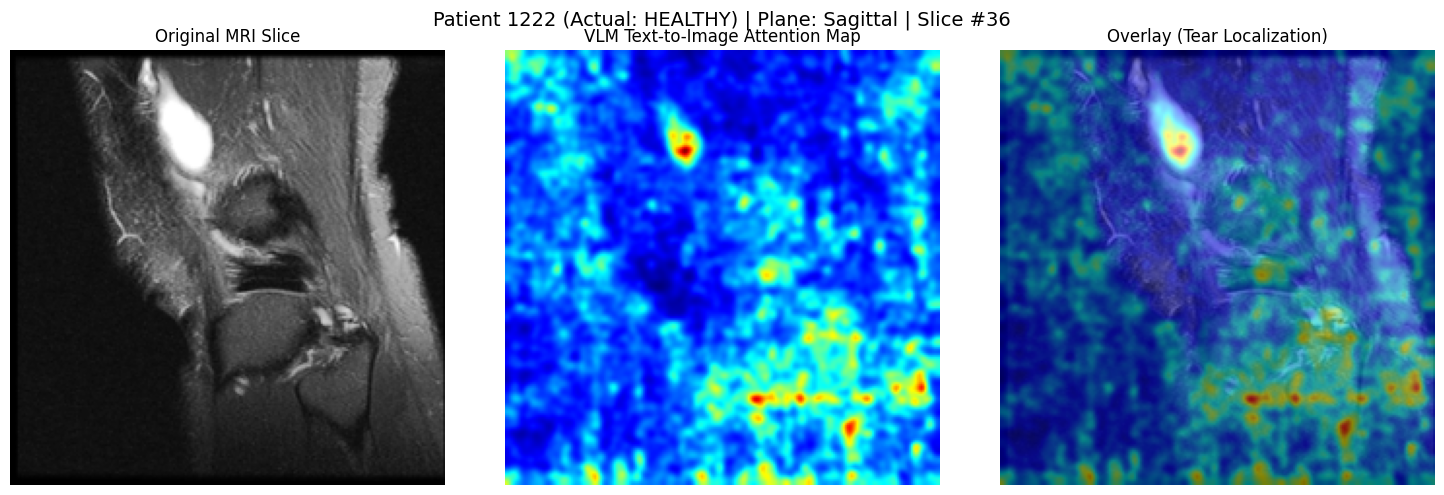

In [ ]:
# healthy
visualize_most_suspicious_slice(patient_idx=5, plane="sagittal")

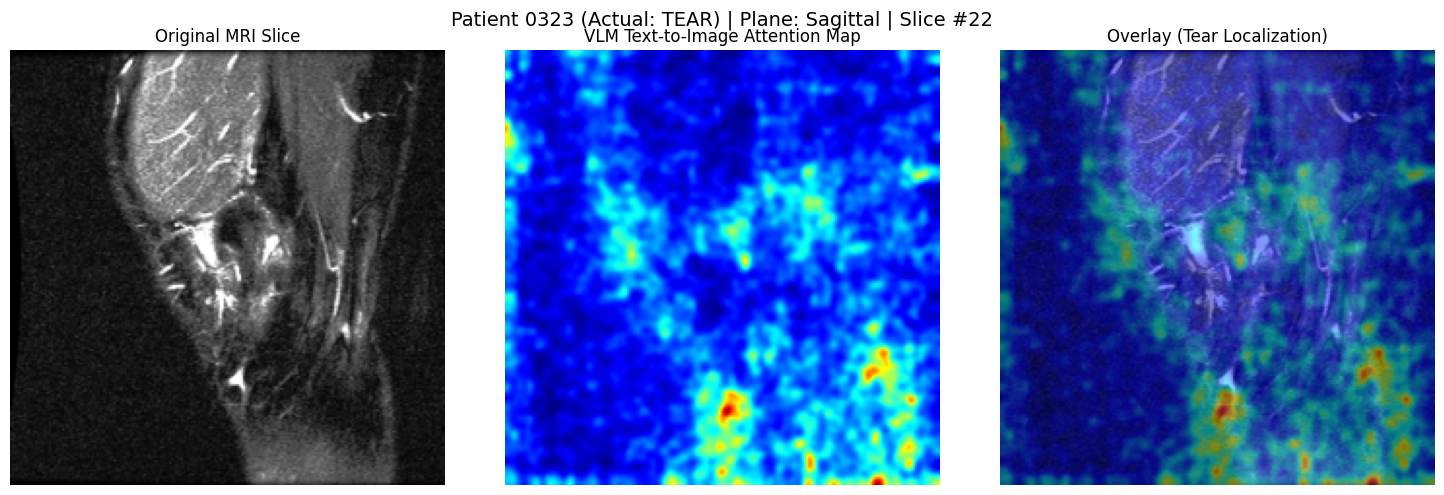

In [ ]:
# tear patient
visualize_most_suspicious_slice(patient_idx=18, plane="sagittal")